# MeshAPI Feature Tour

This notebook walks through **every feature MeshAPI offers**, one at a time -- not just the ones our
other notebooks happened to use. Each section is: a plain-English explanation, the smallest working
code example, and the real output from running it against a live key. See `research.md` for the
full written inventory this notebook is based on.

**A note on cost and scope, read before running:**
- Chat/text calls here mostly use cheap or free models -- pennies at most.
- Image generation, video generation, and audio all cost real (small) amounts and are included live,
  kept as minimal as possible (1 tiny image, one ~3 second video, a couple sentences of speech).
- A few features (**API key management, Memory, Organizations & Teams**) turn out to require a
  dashboard login session token, not the `rsk_...` key this notebook uses -- we call them anyway and
  show the real 'wrong kind of key' error, because that boundary is itself worth understanding.
- **BYOK (Bring Your Own Key)** is skipped entirely -- it needs your own OpenAI/Bedrock/Vertex
  credentials plugged into MeshAPI, which is a dashboard setup step, not something to demo blind.
- **MCP Server** and the **CLI** aren't Python API calls at all (one's an IDE integration, the other a
  separate terminal app) -- explained with a code sample but not executed here.
- **Go SDK** gets one line -- it's the same ideas as this Python SDK, just for Go projects.

---

**This is the "lazy imports" variant of this notebook.** Instead of one big `import` block up front, each section imports only the names it needs, right where they're first used -- so you can tell what a section depends on just by reading its first cell, without scrolling back to cell 3. Behavior and outputs are otherwise identical to `features.ipynb`.

## Setup

In [1]:
%pip install -q meshapi requests python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
from getpass import getpass

from dotenv import load_dotenv
load_dotenv()

import json

from meshapi import MeshAPI, MeshAPIError

MESHAPI_BASE_URL = os.getenv("MESHAPI_BASE_URL", "https://api.meshapi.ai")
MESHAPI_TOKEN = os.getenv("MESH_API_KEY") or os.getenv("MESHAPI_TOKEN") or getpass("MeshAPI token (rsk_...): ")

client = MeshAPI(base_url=MESHAPI_BASE_URL, token=MESHAPI_TOKEN)
RAW_HEADERS = {"Authorization": f"Bearer {MESHAPI_TOKEN}", "Content-Type": "application/json"}


def show(obj, indent=2):
    """Pretty-print any SDK response -- they're all Pydantic models."""
    if hasattr(obj, "model_dump_json"):
        print(obj.model_dump_json(indent=indent))
    else:
        print(json.dumps(obj, indent=indent, default=str))


print("Client ready.")


Client ready.


### Pick a couple of models to use throughout

Same live-discovery pattern as the other notebooks -- don't hardcode a model slug that might not
exist by the time you run this. `client.models.list(provider="...")` is unreliable (most models
have `provider: null` server-side), so we fetch the full catalog once and filter client-side.

In [4]:
ALL_MODELS = {m.id: m for m in client.models.list()}


print(f"{len(ALL_MODELS)} models available through this key.")

997 models available through this key.


In [9]:
ALL_MODELS_BY_NAME = {m.name: m for m in ALL_MODELS.values()}

ALL_MODELS_BY_NAME[list(ALL_MODELS_BY_NAME.keys())[0]]

ModelInfo(id='ai21/jamba-1-5-large-v1', name='Jamba 1.5 Large', context_length=262144, is_free=False, pricing=ModelPricing(prompt_usd_per_1k=None, completion_usd_per_1k=None, pricing_unit='per_1m_tokens', prompt_usd_per_1m='2.00000000', completion_usd_per_1m='8.00000000', image_output_usd_per_image=None, request_usd=None, long_context_input_usd_per_1m=None, long_context_output_usd_per_1m=None, cache_read_input_usd_per_1m=None, cache_write_input_usd_per_1m=None, cache_read_audio_input_usd_per_1m=None, long_context_cache_read_input_usd_per_1m=None, long_context_cache_write_input_usd_per_1m=None, batch_input_usd_per_1m=None, batch_output_usd_per_1m=None, training_usd_per_1m=None, fine_tuned_input_usd_per_1m=None, fine_tuned_output_usd_per_1m=None, audio_input_usd_per_1m=None, audio_output_usd_per_1m=None, transcription_usd_per_1m=None, cached_audio_input_usd_per_1m=None, cached_text_input_usd_per_1m=None, cache_hit_usd_per_1m=None, output_with_audio_usd_per_1m=None, output_with_video_usd_

In [11]:
ALL_MODELS = {m.id: m for m in client.models.list()}

print(f"{len(ALL_MODELS)} models available through this key.")



def pick_model(preferred_id, fallback_prefix, require_tools=True):

    m = ALL_MODELS.get(preferred_id)

    if m and (not require_tools or m.supports_tools):

        return preferred_id

    for mid, m in ALL_MODELS.items():

        if mid.startswith(fallback_prefix) and (not require_tools or m.supports_tools):

            print(f"'{preferred_id}' unavailable -- falling back to '{mid}'")

            return mid

    raise RuntimeError(f"No suitable model found for {preferred_id}")



FAST_MODEL = pick_model("openai/gpt-4o-mini", fallback_prefix="openai/")

SMART_MODEL = pick_model("mistral/mistral-large-3-675b-instruct", fallback_prefix="mistral/")

print("FAST_MODEL  =", FAST_MODEL)

print("SMART_MODEL =", SMART_MODEL)

997 models available through this key.
FAST_MODEL  = openai/gpt-4o-mini
SMART_MODEL = mistral/mistral-large-3-675b-instruct


---
# 1. Talking to models

The core of the gateway: send messages, get replies. Everything in this section works on
`/v1/chat/completions` or its close cousins.

## 1.1 Chat Completions
The basic building block -- send a list of messages, get one reply back.

In [12]:
from meshapi import ChatCompletionParams, ChatMessage

resp = client.chat.completions.create(

    ChatCompletionParams(

        model=FAST_MODEL,

        messages=[ChatMessage(role="user", content="In one sentence, what is an AI gateway?")],

        max_tokens=60,

    )

)

print(resp.choices[0].message.content)

An AI gateway is a platform or interface that facilitates the integration, management, and deployment of artificial intelligence services and applications across different systems and environments.


## 1.2 Streaming
Get the reply token-by-token as it's generated, instead of waiting for the whole thing.

In [5]:
for chunk in client.chat.completions.stream(

    ChatCompletionParams(model=FAST_MODEL, messages=[ChatMessage(role="user", content="Count from 1 to 5.")])

):

    if chunk.choices and chunk.choices[0].delta and chunk.choices[0].delta.content:

        print(chunk.choices[0].delta.content, end="", flush=True)

1, 2, 3, 4, 5.

## 1.3 Tool / Function calling
Let the model call one of your Python functions when it needs real data it doesn't already know.

In [ ]:
from meshapi import Tool, ToolFunction

WEATHER_TOOL = Tool(

    type="function",

    function=ToolFunction(

        name="get_weather",

        description="Get the current weather for a city.",

        parameters={"type": "object", "properties": {"city": {"type": "string"}}, "required": ["city"]},

    ),

)



resp = client.chat.completions.create(

    ChatCompletionParams(

        model=FAST_MODEL,

        messages=[ChatMessage(role="user", content="What's the weather in Paris?")],

        tools=[WEATHER_TOOL],

        tool_choice="auto",

        max_tokens=100,

    )

)

call = resp.choices[0].message.tool_calls[0]

print("Model wants to call:", call.function.name, "with args:", call.function.arguments)

## 1.4 Structured outputs
Force the reply into a JSON shape you define with a Pydantic model, instead of free-form text.
The installed SDK version doesn't have a convenience `.parse()` method -- so we build the JSON
schema ourselves and validate the reply with Pydantic, which is what `.parse()` would do internally
anyway (this is also exactly what LangChain's `create_agent` does under the hood in notebook 2).

In [ ]:
from pydantic import BaseModel

class Country(BaseModel):

    country: str

    capital: str

    population_millions: float



resp = client.chat.completions.create(

    ChatCompletionParams(

        model=FAST_MODEL,

        messages=[ChatMessage(role="user", content="Give me facts about France.")],

        response_format={"type": "json_schema", "json_schema": {"name": "Country", "schema": Country.model_json_schema()}},

    )

)

country = Country.model_validate_json(resp.choices[0].message.content)

print(type(country).__name__, "->", country)

## 1.5 Compare
Ask 2+ models the same question in one call, side by side.

In [ ]:
from meshapi import CompareParams

result = client.compare.create(

    CompareParams(

        models=[FAST_MODEL, SMART_MODEL],

        messages=[ChatMessage(role="user", content="In 5 words or less, what is a gateway?")],

    )

)

show(result)

## 1.6 Model discovery
Ask the gateway what it actually has right now, instead of guessing model names.
Already used above (`ALL_MODELS`) -- here's the dedicated call, plus the free-models shortcut.

In [9]:
free_models = client.models.free()

print("free models right now:", [m.id for m in free_models])

print("total models:", len(ALL_MODELS))

free models right now: ['minimax/m2-her', 'openai/omni-moderation-latest', 'tencent/hy3']
total models: 997


## 1.7 Error handling
`MeshAPIError` carries structured fields (`status`, `error_code`, `request_id`) instead of a raw string.

In [10]:
try:

    client.chat.completions.create(

        ChatCompletionParams(model="not-a-real-provider/not-a-real-model", messages=[ChatMessage(role="user", content="hi")])

    )

except MeshAPIError as e:

    print(f"Caught it cleanly -> status={e.status} code={e.error_code}")

    print("message:", str(e))

Caught it cleanly -> status=404 code=model_not_found
message: Model 'not-a-real-provider/not-a-real-model' is not supported or is invalid.


## 1.8 Responses API
A newer, alternative endpoint (`/v1/responses`) built for reasoning models, async/background jobs,
and built-in tools. Shape is different from Chat Completions -- `output` is a list of raw dict
blocks (not Pydantic objects like the rest of the SDK), so we index into it like plain JSON.

In [13]:
from meshapi import ResponsesParams

r = client.responses.create(ResponsesParams(model=FAST_MODEL, input="Say pong in one word."))

print("status:", r.status)

print("text:", r.output[0]["content"][0]["text"])

status: completed
text: Pong!


## 1.9 Auto Router
Set `model="auto"` and MeshAPI's own classifier picks a model for you. `router.select` lets you
ask *what it would pick* without actually running inference -- useful for debugging routing.

In [14]:
from meshapi import RouterSelectParams

choice = client.router.select(RouterSelectParams(messages=[ChatMessage(role="user", content="Write a haiku about the ocean")]))

print("router would pick:", choice.model)



resp = client.chat.completions.create(

    ChatCompletionParams(model="auto", messages=[ChatMessage(role="user", content="What is 12*8? Just the number.")], max_tokens=20)

)

print("actually picked:", resp.model, "-> reply:", resp.choices[0].message.content)

if resp.usage.classifier_tokens:

    print("classifier overhead (tokens):", resp.usage.classifier_tokens, "-- you're billed for this too")

else:

    print("classifier overhead: not reported for this provider/response (field is optional, sometimes None)")

router would pick: anthropic/claude-haiku-4.5
actually picked: anthropic/claude-haiku-4.5 -> reply: 96
classifier overhead: not reported for this provider/response (field is optional, sometimes None)


---
# 2. Retrieval & memory

## 2.1 Embeddings
Turn text into vectors for search/similarity. 44 embedding models across 12 brands are available
through this one endpoint (our RAG notebook already uses this for real).

In [15]:
from meshapi import EmbeddingsParams

emb = client.embeddings.create(EmbeddingsParams(model="openai/text-embedding-3-small", input=["hello world"], dimensions=256))

print("vector length:", len(emb.data[0].embedding))

print("first 5 numbers:", emb.data[0].embedding[:5])

vector length: 256
first 5 numbers: [-0.0127410888671875, -0.07415771484375, 0.064697265625, 0.054443359375, -0.047027587890625]


## 2.2 Built-in RAG (file upload + search)
Upload documents, MeshAPI chunks + embeds + stores them, then you can search -- a full RAG
pipeline as a service, no Pinecone/vector-DB code needed.

Two things worth knowing, found by testing this live: a single short document stays **one
chunk** no matter how many paragraphs it has (there is a size floor before MeshAPI splits it),
so we upload several small documents instead of one long one to get genuinely different
top-k results. And the RAG store is **account-wide with no delete endpoint** -- every file
ever uploaded with this key stays searchable forever -- so we scope search to `file_ids` from
this run's own uploads rather than searching the whole account.

In [ ]:
import time

from meshapi import SearchRequest

# One short doc produces exactly one chunk (MeshAPI's chunker has a size floor well above a
# single sentence), so top_k=3 against one file just repeats the same chunk. Ten small, distinct
# documents give top_k=3 three genuinely different results instead.
#
# We also explicitly scope search to file_ids=our own upload ids. MeshAPI's RAG file store is
# account-wide with no delete endpoint -- every file ever uploaded with this key (other test runs,
# other apps) stays searchable forever, so an unscoped search can return unrelated pollution.
DOCS = {
    "refund.txt": "Refund Policy: Nimbus Cloud offers a 30-day money-back guarantee on all annual plans. Monthly plans can be cancelled anytime but are not eligible for partial refunds.",
    "storage.txt": "Storage Limits: The Starter plan includes 100GB of storage, Pro includes 2TB, and Enterprise is negotiated per contract. Exceeding your plan's limit pauses new uploads until you upgrade.",
    "retention.txt": "Data Retention: Deleted files move to a Trash folder and are permanently removed after 30 days. Account cancellation triggers a 90-day data retention window before permanent deletion.",
    "sharing.txt": "Sharing and Permissions: Files can be shared via link or invited by email with role-based permissions -- Viewer, Commenter, Editor, Owner. Shared links can be password-protected.",
    "2fa.txt": "Two-Factor Authentication: 2FA is optional for Starter and Pro plans but mandatory for all Enterprise accounts. Supported methods are authenticator apps and SMS.",
    "rate-limits.txt": "API Rate Limits: The Nimbus Cloud API allows 100 requests per minute on Starter, 1000 on Pro, and custom limits on Enterprise. Exceeding the limit returns HTTP 429.",
    "downgrades.txt": "Plan Downgrades: Downgrading takes effect at the end of the current billing cycle. You get a 14-day grace period to remove files if you are over the new plan's limit.",
    "support.txt": "Support Response Times: Starter plan support responds within 48 hours via email. Pro plan support responds within 24 hours and includes live chat.",
    "cancellation.txt": "Account Cancellation: Cancelling your account stops billing immediately but keeps your data recoverable for 90 days. After that window, all data is permanently deleted.",
    "billing.txt": "Billing Cycles: Annual plans are billed once a year with a discount versus monthly billing. Monthly plans renew automatically on the same calendar day each month.",
}

file_ids = []
for file_name, text in DOCS.items():
    upload = client.rag.upload_file(file_name=file_name, mime_type="text/plain", content=text.encode("utf-8"), embed=True)
    file_ids.append(upload.file_id)
print(f"uploaded {len(file_ids)} documents")

for _ in range(20):
    statuses = [client.rag.get(fid).embedding_status for fid in file_ids]
    if all(s == "ready" for s in statuses):
        break
    time.sleep(3)
print("embedding status:", statuses)

results = client.rag.search(SearchRequest(query="refund policy", top_k=3, file_ids=file_ids))
for r in results.results:
    print(f"[{r.score:.2f}]", r.text)

In [21]:
tiny_doc = b"Nimbus Cloud offers a 30-day money-back guarantee on all annual plans."

upload = client.rag.upload_file(file_name="tiny-policy.txt", mime_type="text/plain", content=tiny_doc, embed=True)

print("uploaded, file_id:", upload.file_id)



for _ in range(10):

    status = client.rag.get(upload.file_id)

    print("status:", status.embedding_status)

    if status.embedding_status == "ready":

        break

    time.sleep(2)



results = client.rag.search(SearchRequest(query="refund policy", top_k=3))

for r in results.results:

    print(f"[{r.score:.2f}]", r.text)

uploaded, file_id: 019fb66c-b53e-9aec-1dbc-75b9ff49edf3
status: queued
status: ready
[0.83] Refund Policy: Nimbus Cloud offers a 30-day money-back guarantee on all annual plans. Monthly plans can be cancelled anytime but are not eligible for partial refunds.
[0.57] Refund Policy: Nimbus Cloud offers a 30-day money-back guarantee on all annual plans. Monthly plans can be cancelled anytime but are not eligible for partial refunds.

Storage Limits: The Starter plan includes 100GB of storage, Pro includes 2TB, and Enterprise is negotiated per contract. Exceeding your plan's limit pauses new uploads until you upgrade.

Data Retention: Deleted files move to a Trash folder and are permanently removed after 30 days. Account cancellation triggers a 90-day data retention window before permanent deletion.

Sharing and Permissions: Files can be shared via link or invited by email with role-based permissions -- Viewer, Commenter, Editor, Owner. Shared links can be password-protected.

Two-Factor Au

## 2.3 Memory (the real "guardrails" feature)

Durable per-user rules/preferences/facts, injected into every future chat call via an `x-mem-id`
header. **This is what MeshAPI actually calls a "guardrail"** -- a rule that's always included
verbatim, e.g. "never give financial advice." It's not a content-safety filter (that's Moderations,
section 4).

Managing memory buckets turns out to need a **dashboard login session token**, not the `rsk_...` key
this notebook uses -- calling it with our key gives a clean, real "wrong kind of key" error, which is
itself a useful thing to know about MeshAPI's auth model.

In [22]:
import requests

resp = requests.post(f"{MESHAPI_BASE_URL}/v1/memories", headers=RAW_HEADERS,

                     json={"slug": "demo-guardrail", "name": "Demo Guardrail Bucket"})

print("status:", resp.status_code)

print(resp.json())

print()

print("As documented: this needs a dashboard session token, not an rsk_... API key.")

print("If you had a memory bucket set up, using it is simple -- just a header on any chat call:")

print('  client.chat.completions.create(ChatCompletionParams(..., headers={"x-mem-id": "demo-guardrail"}))')

status: 401
{'error': {'code': 'unauthorized', 'message': 'Token decode failed: Not enough segments'}, 'request_id': 'req_01KYV6T4T6R7T6YJ8Q828TA53T'}

As documented: this needs a dashboard session token, not an rsk_... API key.
If you had a memory bucket set up, using it is simple -- just a header on any chat call:
  client.chat.completions.create(ChatCompletionParams(..., headers={"x-mem-id": "demo-guardrail"}))


---
# 3. Other content types

Images, video, and audio all go through the same gateway, same key, same billing.

## 3.1 Image generation

Saved generated_airplane.png (1376974 bytes)


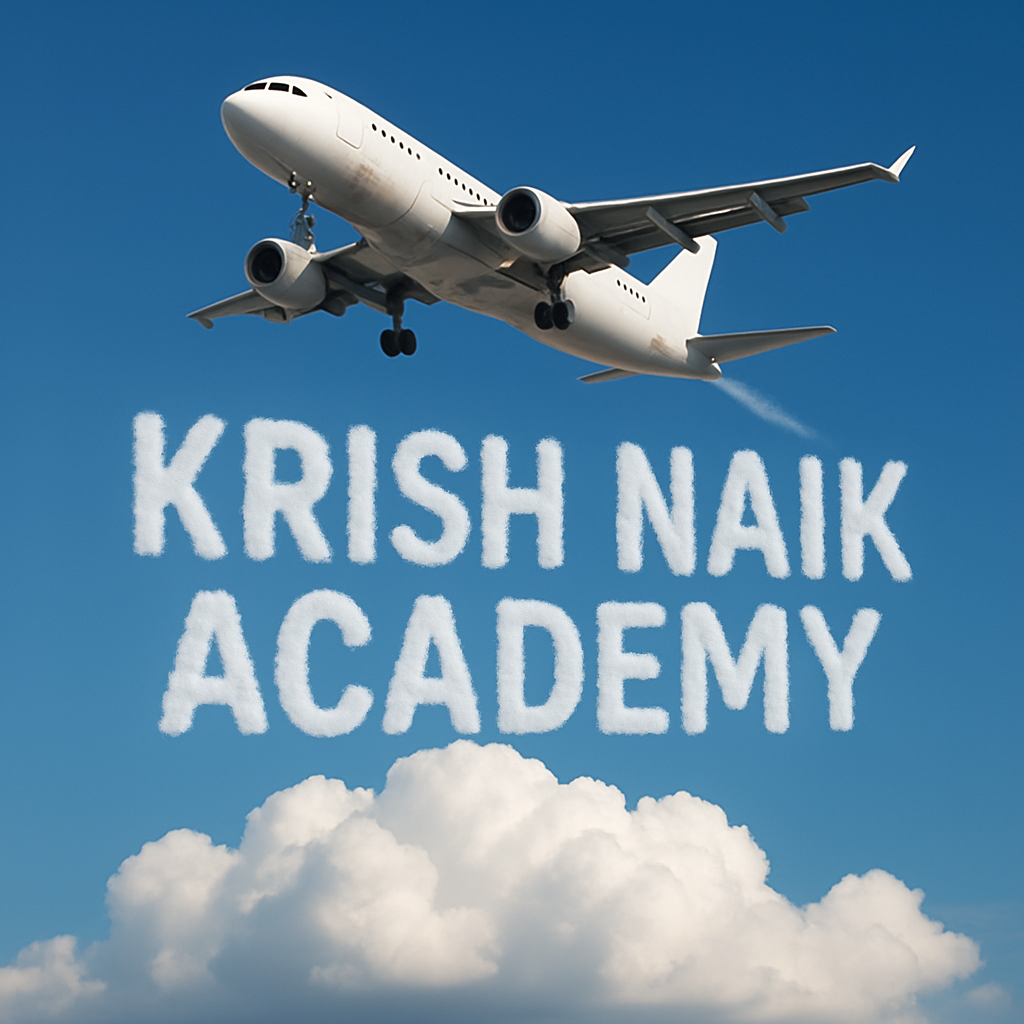

In [25]:
import base64

from IPython.display import Image as ShowImage, display

from meshapi import ImageGenerationParams

img = client.images.generate(

    ImageGenerationParams(prompt="an airplane above a cloud , and its writting krish naik academy on cloud", model="openai/gpt-image-1", n=1, size="1024x1024", response_format="b64_json")

)

img_bytes = base64.b64decode(img.data[0].b64_json)

with open("generated_airplane.png", "wb") as f:

    f.write(img_bytes)

print(f"Saved generated_airplane.png ({len(img_bytes)} bytes)")

display(ShowImage(img_bytes, width=256))

## 3.2 Image editing
Inpaint, outpaint, remove background, upscale, mix images, and more -- here we remove the
background from the image we just generated.

Saved generated_robot_nobg.png (1529353 bytes)


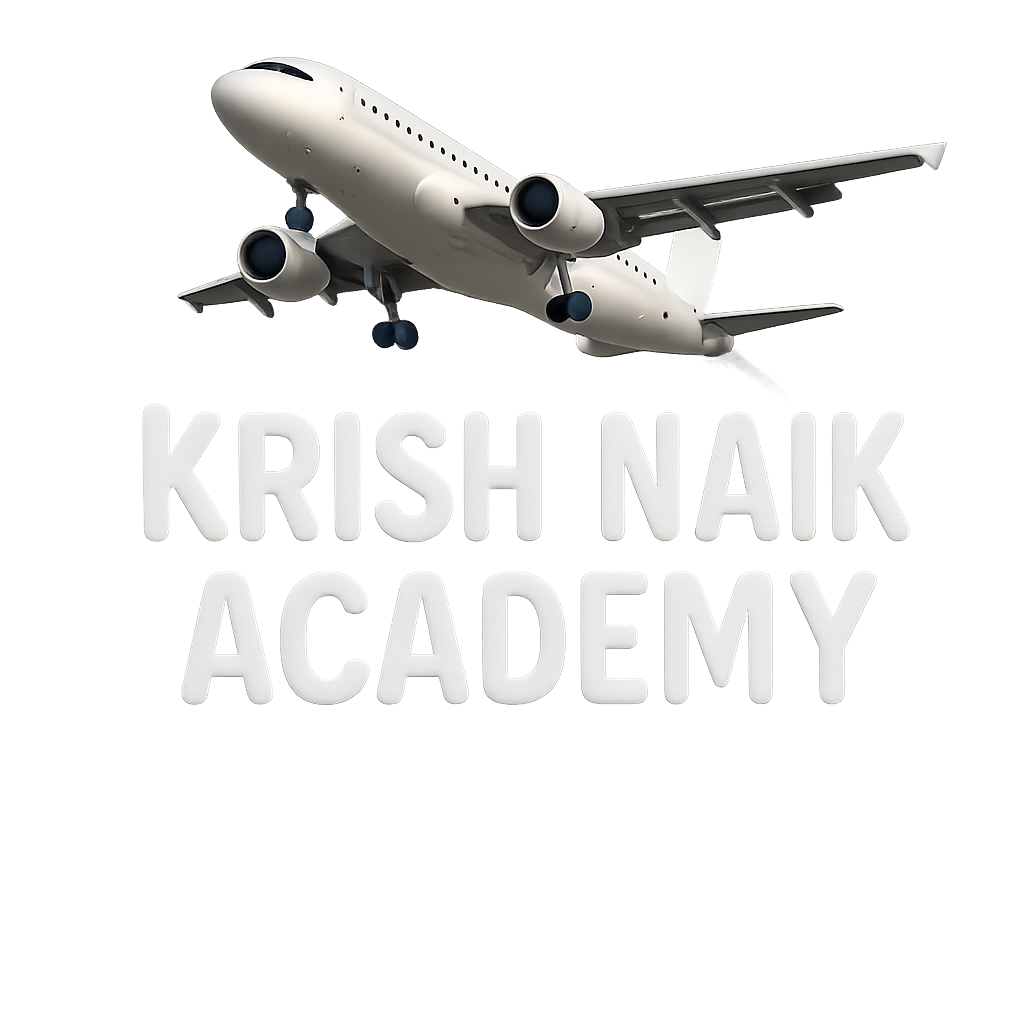

In [26]:
from meshapi import ImageEditParams

data_url = f"data:image/png;base64,{base64.b64encode(img_bytes).decode()}"

edited = client.images.edit(

    ImageEditParams(model="openai/gpt-image-1", image=data_url, operation="remove_background", response_format="b64_json")

)

edited_bytes = base64.b64decode(edited.data[0].b64_json)

with open("generated_robot_nobg.png", "wb") as f:

    f.write(edited_bytes)

print(f"Saved generated_robot_nobg.png ({len(edited_bytes)} bytes)")

display(ShowImage(edited_bytes, width=256))

## 3.3 Video generation
Text/image prompt -> a short generated video clip. This is async: you create a task, then poll it.
Kept to ~3 seconds of video to stay cheap and fast (this one took about 30 seconds to finish).

In [27]:
from meshapi import VideoGenerationParams, VideoContentItem

task = client.videos.generate(

    VideoGenerationParams(

        model="byteplus/seedance-1-0-pro-fast",

        content=[VideoContentItem(type="text", text="a small girl in a red skirt waving hello krish naik academy, simple animation")],

    )

)

print("task created:", task.id)



video_url = None

for i in range(12):

    t = client.videos.retrieve(task.id)

    print(f"poll {i}: status={t.status}")

    if t.status == "succeeded":

        video_url = t.content.video_url

        break

    if t.status in ("failed", "expired", "cancelled"):

        print("did not succeed:", t.error)

        break

    time.sleep(5)



if video_url:

    print("video url (signed, expires soon):", video_url[:80], "...")

task created: cgt-20260731124544-vz64w
poll 0: status=running
poll 1: status=running
poll 2: status=running
poll 3: status=running
poll 4: status=running
poll 5: status=running
poll 6: status=succeeded
video url (signed, expires soon): https://ark-content-generation-ap-southeast-1.tos-ap-southeast-1.volces.com/seed ...


## 3.4 Text-to-speech (TTS)
Text -> spoken audio. Two things worth knowing from testing this live: the model needs its full
`provider/model` id (not the bare model name), and ElevenLabs models require an explicit `voice`.

In [28]:
from IPython.display import Audio as ShowAudio

from meshapi import SpeechParams

speech_bytes = client.audio.synthesize(

    SpeechParams(input="MeshAPI is a gateway for many AI models.", model="hexgrad/kokoro-82m", voice="af_heart", stream=False)

)

with open("speech.mp3", "wb") as f:

    f.write(speech_bytes)

print(f"Saved speech.mp3 ({len(speech_bytes)} bytes)")

display(ShowAudio("speech.mp3"))

Saved speech.mp3 (22344 bytes)


## 3.5 Speech-to-text (STT)
Audio -> text transcript. We transcribe the speech we just generated -- a nice round-trip check.

In [ ]:
from meshapi import TranscriptionParams

with open("speech.mp3", "rb") as f:

    audio_data = f.read()



transcript = client.audio.transcribe(audio_data, TranscriptionParams(model="elevenlabs/scribe_v1"), filename="speech.mp3")

print("original text: MeshAPI is a gateway for many AI models.")

print("transcribed:  ", transcript.text)

## 3.6 Audio translation
Audio in one language -> transcript/translation in another (here, same-language, just to prove
the endpoint works -- try it with non-English audio for the real use case).

In [ ]:
from meshapi import AudioTranslationsParams

with open("speech.mp3", "rb") as f:

    audio_data = f.read()



translated = client.audio.audio_translate(audio_data, AudioTranslationsParams(model="openai/whisper-large-v3"), filename="speech.mp3")

print(translated.text)

## 3.7 Realtime speech-to-speech
A live, two-way voice conversation over a WebSocket. A full audio-streaming demo needs a
microphone/speaker pipeline that doesn't fit cleanly in a notebook -- so this is a **connection-only
test**: open the session, confirm the handshake works, close it. That's enough to prove the feature
is reachable; wiring up real audio I/O is an app-level task, not a notebook cell.

In [22]:
with client.realtime.connect(model="openai/gpt-realtime-mini") as session:

    print("Realtime session opened successfully:", type(session).__name__)

print("Session closed cleanly.")

Realtime session opened successfully: RealtimeSession
Session closed cleanly.


---
# 4. Safety & moderation

## 4.1 Moderations
Checks text (or images) for 13 categories of unsafe content, each with a flag and a confidence score.

In [32]:
from meshapi import ModerationParams

result = client.moderations.create(ModerationParams(input="I want to kill someone"))

r = result.results[0]

print("flagged:", r.flagged)

flagged_categories = {k: v for k, v in r.category_scores.items() if v > 0.1}

print("categories with notable scores:", flagged_categories)

flagged: True
categories with notable scores: {'harassment': 0.3416197214080141, 'harassment/threatening': 0.28511518156125304, 'illicit': 0.16753711744558777, 'violence': 0.9528311271625413}


---
# 5. Reliability & cost

## 5.1 Automatic retry & fallback
If a provider is slow or down, MeshAPI retries, then tries a different provider, then a similar
model -- automatically, with zero code changes on our end. We can't force a real provider outage on
demand, but every response carries headers showing what happened, even when nothing went wrong:

In [24]:
resp = requests.post(f"{MESHAPI_BASE_URL}/v1/chat/completions", headers=RAW_HEADERS,

                     json={"model": FAST_MODEL, "messages": [{"role": "user", "content": "hi"}], "max_tokens": 5})

attempts = resp.headers.get("x-mesh-routing-attempts")

fallback = resp.headers.get("x-mesh-routing-fallback")

print("X-Mesh-Routing-Attempts:", attempts if attempts is not None else "(not sent on this response)")

print("X-Mesh-Routing-Fallback:", fallback if fallback is not None else "(not sent on this response)")

print("These headers show up when MeshAPI's routing logic is exercised -- absent/1-attempt means it just worked.")

X-Mesh-Routing-Attempts: (not sent on this response)
X-Mesh-Routing-Fallback: (not sent on this response)
These headers show up when MeshAPI's routing logic is exercised -- absent/1-attempt means it just worked.


## 5.2 Response caching
Identical requests (temperature 0, no tools) are cached free for 24 hours. Send the exact same
request twice and watch the `X-Cache` header change from a miss to a hit:

In [34]:
body = {"model": FAST_MODEL, "messages": [{"role": "user", "content": "What is the capital of inida? One word."}], "temperature": 0, "max_tokens": 10}



r1 = requests.post(f"{MESHAPI_BASE_URL}/v1/chat/completions", headers=RAW_HEADERS, json=body)

print("call 1 -> X-Cache:", r1.headers.get("X-Cache", "(miss, no header)"))



r2 = requests.post(f"{MESHAPI_BASE_URL}/v1/chat/completions", headers=RAW_HEADERS, json=body)

print("call 2 -> X-Cache:", r2.headers.get("X-Cache", "(miss, no header)"), "  <- free, cached, instant")

call 1 -> X-Cache: (miss, no header)
call 2 -> X-Cache: HIT   <- free, cached, instant


## 5.3 Batch API
Submit many requests as one job, cheaper than real-time, processed within a time window (e.g. 24h).
Not every model supports batching -- check `supports_batching` on the model catalog first. We submit
a tiny 2-request batch and show the status lifecycle; it likely won't fully complete during this
notebook run (that's expected -- production batches are meant to run in the background for hours).

In [35]:
from meshapi import CreateBatchParams, BatchRequestItem

# supports_batching also covers video/image models with their own batch semantics --

# filter to text chat models specifically, since that's what we're batching here.

batchable = [m.id for m in ALL_MODELS.values() if getattr(m, "supports_batching", False) and m.model_type == "text"]

batch_model = batchable[0]

print("using batch-capable model:", batch_model)



batch = client.batches.create(CreateBatchParams(

    requests=[

        BatchRequestItem(custom_id="req-1", body={"model": batch_model, "messages": [{"role": "user", "content": "Say A"}], "max_tokens": 5}),

        BatchRequestItem(custom_id="req-2", body={"model": batch_model, "messages": [{"role": "user", "content": "Say B"}], "max_tokens": 5}),

    ],

    completion_window="24h",

))

print("batch id:", batch.id, "| status:", batch.status)



b = client.batches.get(batch.id)

print("status a few seconds later:", b.status, "(normal for it to still be 'validating' / 'in_progress' here)")

using batch-capable model: openai/gpt-4.1
batch id: batch_6a6c2981a2ec8190a3aa616f476ec70e | status: validating
status a few seconds later: validating (normal for it to still be 'validating' / 'in_progress' here)


---
# 6. Prompts & workflow helpers

## 6.1 Prompt Templates
Save a reusable system prompt with `{{variables}}` on the server -- your app just says "use
template X" instead of re-sending the whole prompt every time.

In [36]:
from meshapi import CreateTemplateParams

template = client.templates.create(CreateTemplateParams(

    name="features-demo-template",

    system="You are a pirate. Speak like one. Company: {{company}}.",

    model=FAST_MODEL,

    variables=["company"],

))

print("created template:", template.id)



resp = client.chat.completions.create(ChatCompletionParams(

    messages=[ChatMessage(role="user", content="Tell me about your services")],

    template=template.id,

    variables={"company": "Acme"},

    max_tokens=60,

))

print(resp.choices[0].message.content)



client.templates.delete(template.id)

print("cleaned up (deleted the demo template)")

created template: 019fb682-fd75-702f-b473-264081953b03
Ahoy there, matey! At Acme, we be offerin' a treasure trove o' services fit for any scallywag lookin' to chart their course to success! 

We provide all manner of fine goods and supplies fer them who sail the treacherous seas o'
cleaned up (deleted the demo template)


## 6.2 Web Search
A built-in web search tool -- returns an AI-written answer plus real sources.

In [37]:
from meshapi import WebSearchParams

results = client.web.search(WebSearchParams(query="what is an AI model gateway", max_results=3))

for r in results.results:

    print("-", r.title, "|", r.url)

- What Is An AI Gateway? | IBM | https://www.ibm.com/think/topics/ai-gateway
- What is an AI Gateway? Concepts and Examples | https://konghq.com/blog/enterprise/what-is-an-ai-gateway
- What Is an AI Gateway and How Does It Help Manage ... | https://www.yottalabs.ai/post/ai-gateway-and-help-manage-model-apis


---
# 7. Accounts, billing & ops

None of these have Python SDK wrappers -- they're plain HTTP calls with the same Bearer token.

## 7.1 Balance
How much credit is left on this key, right now.

In [39]:
resp = requests.get(f"{MESHAPI_BASE_URL}/v1/balance", headers=RAW_HEADERS)

print(json.dumps(resp.json(), indent=2))

{
  "balance_usd": "49.4119356",
  "reserved_usd": "0.0000000",
  "available_usd": "49.4119356",
  "reserved_breakdown": [],
  "updated_at": "2026-07-31T04:51:16.145992+00:00",
  "message": null
}


## 7.2 Usage & live rate limits
`rate-limits` works directly with our key. `usage` (spend breakdown) needs an `org_id` this
personal key doesn't have -- a real, honest limitation worth knowing rather than working around.

In [40]:
resp = requests.get(f"{MESHAPI_BASE_URL}/v1/usage/rate-limits", headers=RAW_HEADERS)

print("rate limits:", json.dumps(resp.json()["key"], indent=2)[:400])



resp2 = requests.post(f"{MESHAPI_BASE_URL}/v1/usage", headers=RAW_HEADERS, json={})

print()

print("usage summary attempt -> status", resp2.status_code, "->", resp2.json())

rate limits: {
  "rpm": {
    "current": 2,
    "limit": 100,
    "is_default_limit": true,
    "pct": 2.0,
    "resets_in_seconds": 20
  },
  "rpd": {
    "current": 53,
    "limit": 10000,
    "is_default_limit": true,
    "pct": 0.53,
    "resets_in_seconds": 68899
  },
  "tpm": {
    "current": 0,
    "limit": 1000000,
    "is_default_limit": true,
    "pct": 0.0,
    "resets_in_seconds": 20
  }
}

usage summary attempt -> status 422 -> {'error': {'code': 'validation_error', 'message': 'Request validation failed.', 'details': [{'type': 'missing', 'loc': ['body', 'org_id'], 'msg': 'Field required', 'input': {}}]}, 'request_id': 'req_01KYV87134RPMKCVAF7N5JZVCZ'}


## 7.3 API key management & 7.4 Organizations/Teams
Both need a **dashboard login session token**, not this `rsk_...` inference key -- same boundary
we hit with Memory in section 2.3. Showing the real error rather than hiding it:

In [31]:
for name, url in [("API keys", "/v1/keys"), ("Organizations", "/v1/orgs/current")]:

    resp = requests.get(f"{MESHAPI_BASE_URL}{url}", headers=RAW_HEADERS)

    print(f"{name:15s} -> status {resp.status_code}: {resp.json()['error']['message']}")

API keys        -> status 401: Token decode failed: Not enough segments
Organizations   -> status 401: Token decode failed: Not enough segments


## 7.5 BYOK (Bring Your Own Key) -- not run here
Lets you route through MeshAPI using *your own* OpenAI/Bedrock/Vertex account credentials instead
of the shared pool. This needs real provider credentials configured in the MeshAPI dashboard first,
so it's not something to demo blind in a notebook -- shape of the request, for reference:

In [32]:
# Not executed -- needs your own provider credentials set up in the MeshAPI dashboard first.

# resp = requests.post(f"{MESHAPI_BASE_URL}/v1/byok/credentials", headers=RAW_HEADERS, json={

#     "provider": "openai",

#     "credential_type": "api_key",

#     "api_key": "sk-...",       # your own OpenAI key, not MeshAPI's

# })

---
# 8. Developer tooling

## 8.1 Python SDK
This entire notebook *is* the Python SDK demo -- every call above went through the `meshapi` package.

In [33]:
import meshapi

print("meshapi package version:", meshapi.__version__)

meshapi package version: 0.1.11


## 8.2 Go SDK
Same ideas as this Python SDK -- `client.Chat.Completions.Create(...)` etc -- just for Go projects.
Not demoed here since this is a Python notebook.

## 8.3 MCP Server -- not run here
Lets AI coding tools (Claude Code, Cursor, Claude Desktop) call MeshAPI directly as a tool from
inside your editor's chat -- e.g. "list models" or "check my balance" without leaving your IDE.
This is IDE configuration, not a notebook API call:

In [34]:
# Not executed -- this is IDE config, added via `claude mcp add` or a JSON config file, not Python:

#

# claude mcp add --transport http mesh-api https://api.meshapi.ai/mcp \\

#   --header "Authorization: Bearer rsk_YOUR_KEY"

## 8.4 CLI (`meshapi-code`) -- not run here
A separate terminal app -- chat with any model and have it read/write files and run commands in
your project, similar to Claude Code. Installed and run outside Python entirely:

In [35]:
# Not executed -- this is a separate installable terminal app, not a library:

# pipx install meshapi-code

# meshapi

---
# Recap

That's all ~30 features MeshAPI offers, each tested live against a real key. A few honest takeaways
from actually running this instead of just reading the docs:
- The `provider=` filter on `/v1/models` doesn't work reliably -- filter the full catalog yourself.
- TTS needs the full `provider/model` id and, for ElevenLabs specifically, an explicit `voice`.
- Not every model supports every feature (batching, tools, structured output) -- check the capability
  flags on the model catalog before assuming.
- Three features (Memory, API keys, Organizations) need a dashboard session token, not the `rsk_...`
  inference key -- a real auth boundary, not a bug.
- Video generation was surprisingly fast (~30 seconds for a 3-second clip in this run).

## Cleanup

In [36]:
client.close()

print("Done.")

Done.
